# 07 - Treino DistilBERT (PyTorch)

Fine-tuning do DistilBERT para classificação de texto.

- **Dataset**: `data/processed/dataset_combined.csv`
- **Validações**: `dataset-exemplos.csv` e `subm1_labels_revealed.csv`
- **Método**: Random search com 20 iterações

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize

from src.data_processing import clean_text
from src.models_pytorch.distilbert import DistilBERTClassifier, DistilBERTDataset, get_tokenizer

In [3]:
# Configuração
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cpu


## 1. Carregamento de Dados

In [4]:
# Constantes
ROOT = os.path.abspath('..')
CLASSES = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
LABEL_MAP = {label: i for i, label in enumerate(CLASSES)}
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES = len(CLASSES)

TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'dataset_combined.csv')
VAL1_PATH = os.path.join(ROOT, 'data', 'validation', 'dataset-exemplos.csv')
VAL2_PATH = os.path.join(ROOT, 'data', 'validation', 'subm1_labels_revealed.csv')

print(f'Classes: {LABEL_MAP}')

Classes: {'Anthropic': 0, 'Google': 1, 'Human': 2, 'Meta': 3, 'OpenAI': 4}


In [ ]:
def load_data(path):
    df = pd.read_csv(path, sep=';')
    df = df[df['Label'].isin(CLASSES)].copy()
    df['label_id'] = df['Label'].map(LABEL_MAP)
    return df

df_train = load_data(TRAIN_PATH)
df_val1 = load_data(VAL1_PATH)
df_val2 = load_data(VAL2_PATH)

print(f'Train: {len(df_train)} amostras')
print(f'  Labels: {df_train["Label"].value_counts().to_dict()}')
print(f'Val1 (exemplos): {len(df_val1)} amostras')
print(f'Val2 (subm1): {len(df_val2)} amostras')

Train: 2195 amostras
  Labels: {'Anthropic': 500, 'OpenAI': 481, 'Google': 480, 'Meta': 480, 'Human': 254}
Val1 (exemplos): 125 amostras
Val2 (subm1): 100 amostras


In [ ]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_train['Text'].tolist(),
    df_train['label_id'].values,
    test_size=0.2,
    random_state=42,
    stratify=df_train['label_id'].values
)

print(f'Train interno: {len(train_texts)}')
print(f'Val interno: {len(val_texts)}')

Train interno: 1756
Val interno: 439


## 2. Tokenizer

In [7]:
print('Carregando tokenizer DistilBERT...')
tokenizer = get_tokenizer()
print(f'Vocab size: {tokenizer.vocab_size}')

Carregando tokenizer DistilBERT...
Vocab size: 30522


## 3. Funções de Treino

In [8]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labs = batch['label'].to(device)
        
        optimizer.zero_grad()
        out = model(input_ids, attention_mask)
        loss = criterion(out, labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item() * len(labs)
        correct += (out.argmax(dim=1) == labs).sum().item()
        total += len(labs)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labs = batch['label'].to(device)
            
            out = model(input_ids, attention_mask)
            loss = criterion(out, labs)
            
            total_loss += loss.item() * len(labs)
            correct += (out.argmax(dim=1) == labs).sum().item()
            total += len(labs)
    return total_loss / total, correct / total

def train_bert(params, train_texts, train_labels, val_texts, val_labels, tokenizer, device):
    """Treina DistilBERT."""
    train_ds = DistilBERTDataset(train_texts, train_labels, tokenizer, max_len=params['max_len'])
    val_ds = DistilBERTDataset(val_texts, val_labels, tokenizer, max_len=params['max_len'])
    
    train_dl = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=params['batch_size'])
    
    model = DistilBERTClassifier(
        output_dim=NUM_CLASSES,
        dropout=params['dropout'],
        freeze_bert=params.get('freeze_bert', False),
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=params['lr'],
        weight_decay=params.get('weight_decay', 0.01)
    )
    
    best_val_acc = 0
    patience_counter = 0
    best_state = None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    t0 = time.time()
    for epoch in range(params['epochs']):
        tr_loss, tr_acc = train_epoch(model, train_dl, optimizer, criterion, device)
        vl_loss, vl_acc = eval_epoch(model, val_dl, criterion, device)
        
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 3:
                break
    
    train_time = time.time() - t0
    model.load_state_dict(best_state)
    
    return model, best_val_acc, max(history['train_acc']), history, train_time

def evaluate_external_bert(model, texts, labels, tokenizer, batch_size, max_len, device):
    """Avalia modelo num dataset externo."""
    ds = DistilBERTDataset(texts, labels, tokenizer, max_len=max_len)
    dl = DataLoader(ds, batch_size=batch_size)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in dl:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labs = batch['label'].to(device)
            out = model(input_ids, attention_mask)
            correct += (out.argmax(dim=1) == labs).sum().item()
            total += len(labs)
    return correct / total

def get_predictions_bert(model, texts, labels, tokenizer, batch_size, max_len, device):
    """Obtém predições e probabilidades."""
    ds = DistilBERTDataset(texts, labels, tokenizer, max_len=max_len)
    dl = DataLoader(ds, batch_size=batch_size)
    model.eval()
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for batch in dl:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            out = model(input_ids, attention_mask)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(batch['label'].numpy())
    return np.vstack(all_probs), np.concatenate(all_labels)

## 4. Param Grid e Random Search

In [ ]:
param_grid = {
    'lr': [2e-5, 3e-5, 5e-5],
    'batch_size': [8, 16],
    'dropout': [0.1, 0.2, 0.3],
    'epochs': [3, 4, 5],
    'max_len': [64, 128],
    'weight_decay': [0.01, 0.001],
    'freeze_bert': [False],
}

print('Opções por parâmetro:')
for k, v in param_grid.items():
    print(f'  {k}: {len(v)} opções')

Opções por parâmetro:
  lr: 3 opções
  batch_size: 2 opções
  dropout: 3 opções
  epochs: 3 opções
  max_len: 2 opções
  weight_decay: 2 opções
  freeze_bert: 1 opções


In [10]:
SEED = 42
N_ITERATIONS = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def sample_params(grid, rng):
    return {k: rng.choice(v) for k, v in grid.items()}

In [11]:
results = []
best_val1_acc = -1
best_model = None
best_params = None

print(f'=== Random Search: DistilBERT — {N_ITERATIONS} iterações ===')
print(f'Device: {DEVICE}')
print()

for i in range(N_ITERATIONS):
    params = sample_params(param_grid, random)
    
    print(f"[{i+1}/{N_ITERATIONS}] lr={params['lr']} bs={params['batch_size']} "
          f"drop={params['dropout']} epochs={params['epochs']} "
          f"max_len={params['max_len']} wd={params['weight_decay']}")
    
    try:
        model, val_acc, train_acc, history, train_time = train_bert(
            params, train_texts, train_labels, val_texts, val_labels,
            tokenizer, DEVICE
        )
        
        val1_acc = evaluate_external_bert(
            model, df_val1['Text'].tolist(), df_val1['label_id'].values,
            tokenizer, params['batch_size'], params['max_len'], DEVICE
        )
        val2_acc = evaluate_external_bert(
            model, df_val2['Text'].tolist(), df_val2['label_id'].values,
            tokenizer, params['batch_size'], params['max_len'], DEVICE
        )
        
        print(f"  -> internal={val_acc:.4f} | val1={val1_acc:.4f} | val2={val2_acc:.4f} ({train_time:.1f}s)")
        
        results.append({
            'iteration': i + 1,
            'lr': params['lr'],
            'batch_size': params['batch_size'],
            'dropout': params['dropout'],
            'epochs': params['epochs'],
            'max_len': params['max_len'],
            'weight_decay': params['weight_decay'],
            'internal_val': val_acc,
            'train_acc': train_acc,
            'val1_acc': val1_acc,
            'val2_acc': val2_acc,
            'train_time': train_time,
        })
        
        if val1_acc > best_val1_acc:
            best_val1_acc = val1_acc
            best_model = model
            best_params = params.copy()
            print(f"  *** NOVO MELHOR ***")
    
    except Exception as e:
        print(f"  -> ERRO: {e}")
        results.append({
            'iteration': i + 1,
            'error': str(e),
            **params
        })

print(f'\n=== Concluído ===')

=== Random Search: DistilBERT — 20 iterações ===
Device: cpu

[1/20] lr=5e-05 bs=8 drop=0.1 epochs=5 max_len=128 wd=0.01


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  -> internal=0.9522 | val1=0.3520 | val2=0.4800 (603.3s)
  *** NOVO MELHOR ***
[2/20] lr=2e-05 bs=8 drop=0.3 epochs=5 max_len=64 wd=0.001


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  -> internal=0.9408 | val1=0.3520 | val2=0.5200 (391.1s)
[8/20] lr=5e-05 bs=8 drop=0.1 epochs=5 max_len=64 wd=0.001


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KeyboardInterrupt: 

## 5. Resultados

In [12]:
results_df = pd.DataFrame(results)
if 'error' in results_df.columns:
    results_df = results_df[results_df['error'].isna()]

if 'val1_acc' in results_df.columns and len(results_df) > 0:
    print('=== Top 5 Modelos (por val1_acc) ===')
    print()
    top5 = results_df.nlargest(5, 'val1_acc')[
        ['iteration', 'lr', 'batch_size', 'dropout', 'epochs',
         'internal_val', 'val1_acc', 'val2_acc']
    ]
    print(top5.to_string(index=False))
    
    print('\n=== Top 5 Modelos (por val2_acc) ===')
    print()
    top5_val2 = results_df.nlargest(5, 'val2_acc')[
        ['iteration', 'lr', 'batch_size', 'dropout', 'epochs',
         'internal_val', 'val1_acc', 'val2_acc']
    ]
    print(top5_val2.to_string(index=False))

=== Top 5 Modelos (por val1_acc) ===

 iteration      lr  batch_size  dropout  epochs  internal_val  val1_acc  val2_acc
         6 0.00003           8      0.2       4      0.938497     0.408      0.54
         1 0.00005           8      0.1       5      0.952164     0.352      0.48
         7 0.00005           8      0.2       3      0.940774     0.352      0.52
         5 0.00003          16      0.1       3      0.954442     0.328      0.51
         2 0.00002           8      0.3       5      0.911162     0.304      0.28

=== Top 5 Modelos (por val2_acc) ===

 iteration      lr  batch_size  dropout  epochs  internal_val  val1_acc  val2_acc
         6 0.00003           8      0.2       4      0.938497     0.408      0.54
         7 0.00005           8      0.2       3      0.940774     0.352      0.52
         5 0.00003          16      0.1       3      0.954442     0.328      0.51
         1 0.00005           8      0.1       5      0.952164     0.352      0.48
         2 0.00002   

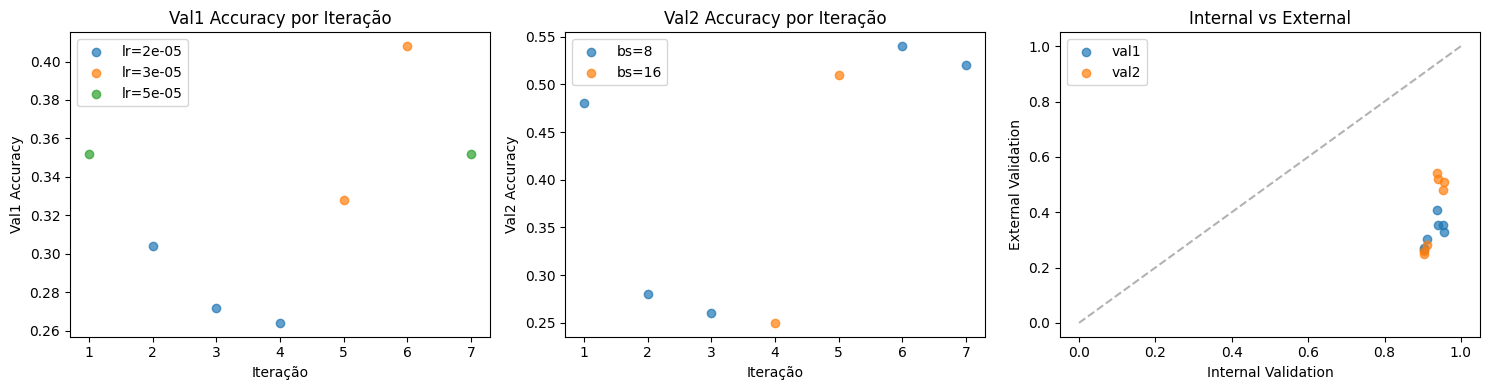

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for lr in sorted(results_df['lr'].unique()):
    mask = results_df['lr'] == lr
    axes[0].scatter(results_df[mask]['iteration'], results_df[mask]['val1_acc'],
                   label=f'lr={lr}', alpha=0.7)
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('Val1 Accuracy')
axes[0].set_title('Val1 Accuracy por Iteração')
axes[0].legend()

for bs in sorted(results_df['batch_size'].unique()):
    mask = results_df['batch_size'] == bs
    axes[1].scatter(results_df[mask]['iteration'], results_df[mask]['val2_acc'],
                   label=f'bs={bs}', alpha=0.7)
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('Val2 Accuracy')
axes[1].set_title('Val2 Accuracy por Iteração')
axes[1].legend()

axes[2].scatter(results_df['internal_val'], results_df['val1_acc'],
               label='val1', alpha=0.7)
axes[2].scatter(results_df['internal_val'], results_df['val2_acc'],
               label='val2', alpha=0.7)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel('Internal Validation')
axes[2].set_ylabel('External Validation')
axes[2].set_title('Internal vs External')
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Avaliação Detalhada do Melhor Modelo

In [14]:
print('=== Melhor Modelo DistilBERT ===')
print(f"LR: {best_params['lr']}")
print(f"Batch size: {best_params['batch_size']}")
print(f"Dropout: {best_params['dropout']}")
print(f"Epochs: {best_params['epochs']}")
print(f"Max length: {best_params['max_len']}")
print(f"Weight decay: {best_params['weight_decay']}")

=== Melhor Modelo DistilBERT ===
LR: 3e-05
Batch size: 8
Dropout: 0.2
Epochs: 4
Max length: 128
Weight decay: 0.01


In [15]:
def full_evaluation_bert(model, texts, labels, name, tokenizer, batch_size, max_len, device):
    probs, labels = get_predictions_bert(model, texts, labels, tokenizer, batch_size, max_len, device)
    preds = np.argmax(probs, axis=1)
    
    acc = accuracy_score(labels, preds)
    
    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print()
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ylabel='Real',
        xlabel='Previsto',
        title=f'Matriz de Confusão — {name}',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    
    plt.tight_layout()
    plt.show()
    
    return probs, labels


=== Val1 (exemplos) ===
Accuracy: 0.4080

              precision    recall  f1-score   support

   Anthropic       0.00      0.00      0.00        23
      Google       0.23      0.44      0.30        16
       Human       0.50      0.63      0.56        52
        Meta       0.46      0.35      0.40        17
      OpenAI       0.42      0.29      0.34        17

    accuracy                           0.41       125
   macro avg       0.32      0.34      0.32       125
weighted avg       0.36      0.41      0.37       125



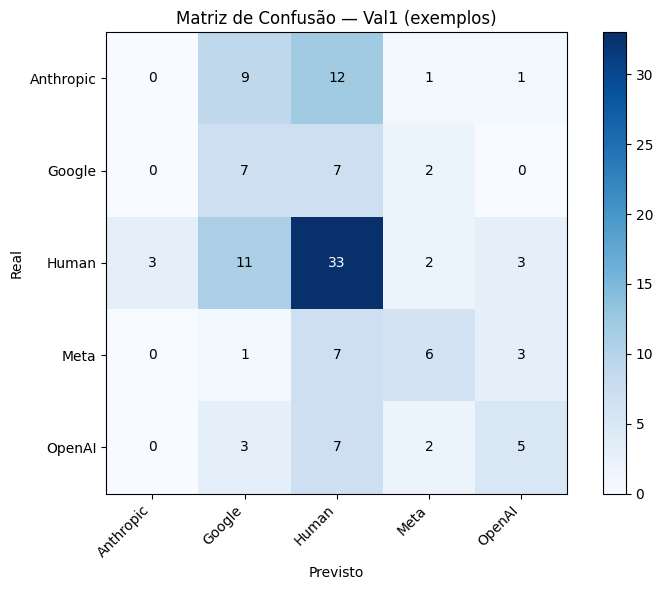


=== Val2 (subm1) ===
Accuracy: 0.5400

              precision    recall  f1-score   support

   Anthropic       0.30      0.18      0.22        17
      Google       0.48      0.65      0.55        17
       Human       0.54      0.62      0.58        34
        Meta       0.81      0.94      0.87        18
      OpenAI       0.29      0.14      0.19        14

    accuracy                           0.54       100
   macro avg       0.48      0.51      0.48       100
weighted avg       0.50      0.54      0.51       100



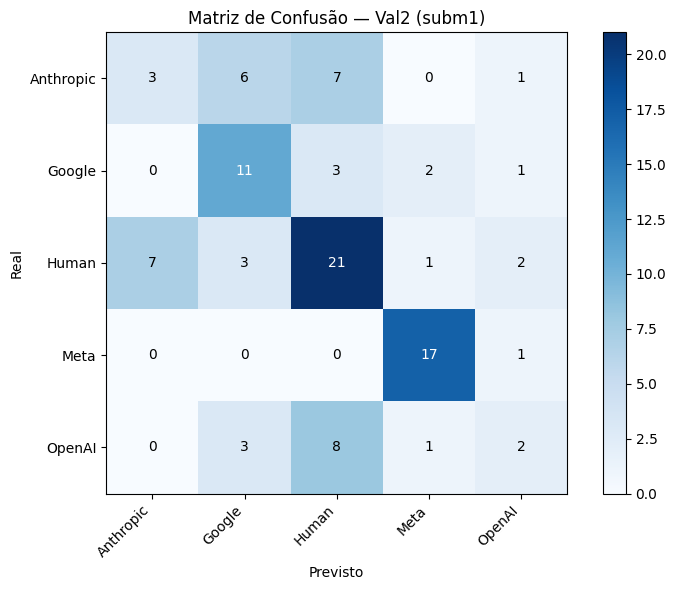

In [16]:
probs_val1, labels_val1 = full_evaluation_bert(
    best_model, df_val1['Text'].tolist(), df_val1['label_id'].values,
    'Val1 (exemplos)', tokenizer, best_params['batch_size'], 
    best_params['max_len'], DEVICE
)
probs_val2, labels_val2 = full_evaluation_bert(
    best_model, df_val2['Text'].tolist(), df_val2['label_id'].values,
    'Val2 (subm1)', tokenizer, best_params['batch_size'],
    best_params['max_len'], DEVICE
)

## 7. Curva ROC (Macro Average)

In [ ]:
def plot_roc_macro(probs, labels, name):
    labels_bin = label_binarize(labels, classes=range(NUM_CLASSES))
    
    fpr, tpr, _ = roc_curve(labels_bin.ravel(), probs.ravel())
    roc_auc = auc(fpr, tpr)
    
    aucs = []
    for i in range(NUM_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(labels_bin[:, i], probs[:, i])
        aucs.append(auc(fpr_i, tpr_i))
    macro_auc = np.mean(aucs)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Micro-average ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Macro AUC = {macro_auc:.3f}) — {name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f'{name}: Micro AUC = {roc_auc:.4f}, Macro AUC = {macro_auc:.4f}')
    return macro_auc

macro_auc_val1 = plot_roc_macro(probs_val1, labels_val1, 'Val1 (exemplos)')
macro_auc_val2 = plot_roc_macro(probs_val2, labels_val2, 'Val2 (subm1)')

## 8. Conclusões

In [ ]:
print('=' * 60)
print('CONCLUSÕES — DistilBERT')
print('=' * 60)
print()

print('Estatísticas por learning rate:')
for lr in sorted(results_df['lr'].unique()):
    mask = results_df['lr'] == lr
    mean_v1 = results_df[mask]['val1_acc'].mean()
    mean_v2 = results_df[mask]['val2_acc'].mean()
    print(f'  lr={lr}: val1={mean_v1:.4f} | val2={mean_v2:.4f}')

print()
print('Melhor configuração:')
print(f"  LR: {best_params['lr']}")
print(f"  Batch size: {best_params['batch_size']}")
print(f"  Dropout: {best_params['dropout']}")
print(f"  Epochs: {best_params['epochs']}")
print(f"  Max length: {best_params['max_len']}")
print()
print(f'Val1 Accuracy: {best_val1_acc:.4f}')
print(f'Val1 AUC (macro): {macro_auc_val1:.4f}')
best_val2 = results_df.loc[results_df['val1_acc'].idxmax(), 'val2_acc']
print(f'Val2 Accuracy: {best_val2:.4f}')
print(f'Val2 AUC (macro): {macro_auc_val2:.4f}')